# Pokémon TCG AI Battle — OSFP self-play training (Phase 5a)

Visualises one **OSFP self-play** run produced by `scripts/train_osfp.py`. We
warm-start from the Phase-4 behaviour-cloning net (`data/bc/bc_net.npz`) and
improve the **play + value heads** with REINFORCE on self-play returns, against a
recency-weighted opponent pool (`random`/`greedy`/`heuristic` + admitted
checkpoints). The deck is **fixed** (`metal_aggro`) in this arm — deck-head
learning is OFF (the 5b ablation arm).

The run logs, every `eval_every` iterations, the learner's **argmax** win rate vs
each fixed opponent (100 games/point — noisy, ±~10pp). The question this notebook
answers: **does self-play RL move strength above the BC starting point?**

In [1]:
import sys, json
from pathlib import Path

# Make `import src...` work whether run from repo root or notebooks/.
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

RUN_DIR = ROOT / "data" / "osfp" / "run1"   # <- point at another run to re-use
hist = json.loads((RUN_DIR / "history.json").read_text())
cfg = hist["config"]
print("run config:", json.dumps(cfg, ensure_ascii=False))
print("checkpoints admitted:", hist["checkpoints"])

df = pd.DataFrame(hist["iterations_log"])
print(f"iterations: {len(df)}")
df.head()

run config: {"iterations": 100, "games_per_iter": 256, "temperature": 1.0, "lr": 0.001, "entropy_coef": 0.01, "eval_every": 10, "seed": 0, "baselines": ["random", "greedy", "heuristic"], "bc_weights": "data/bc/bc_net.npz", "deck": "decklists/metal_aggro.csv"}
checkpoints admitted: 33
iterations: 100


,iteration,opponent,n_games,n_samples,winrates,admitted,ckpts_after
0,1,random,256,13360,{},False,0
1,2,self,256,45119,{},False,0
2,3,self,256,26559,{},True,1
3,4,iter_3.npz,256,10520,{},False,1
4,5,iter_3.npz,256,9736,{},False,1


## 1. Win-rate curve vs the fixed opponents

The headline chart. Each eval point is the learner's argmax win rate over 100
games vs that opponent. Reference lines: **0.5** (even) and **BC's Phase-4
strength vs heuristic (0.604)**. The ★ marks the clean **N=500** eval of the
final checkpoint (much tighter than the 100-game in-loop points).

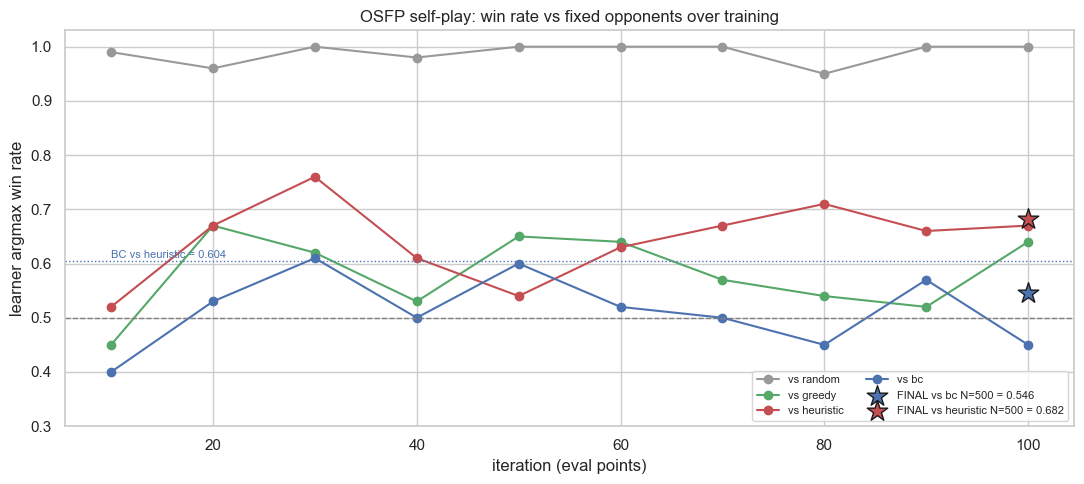

In [2]:
evals = df[df["winrates"].map(len) > 0].copy()
wr = pd.json_normalize(list(evals["winrates"]))
wr.index = list(evals["iteration"])

fig, ax = plt.subplots(figsize=(11, 5))
palette = {"random": "#999999", "greedy": "#55a868",
           "heuristic": "#c44e52", "bc": "#4c72b0"}
for opp in wr.columns:
    ax.plot(wr.index, wr[opp], marker="o", label=f"vs {opp}",
            color=palette.get(opp))

ax.axhline(0.5, ls="--", c="grey", lw=1)
ax.axhline(0.604, ls=":", c="#4c72b0", lw=1)
ax.text(wr.index.min(), 0.61, "BC vs heuristic = 0.604", fontsize=8, color="#4c72b0")

fe = hist.get("final_eval_n500", {})
if fe:
    x = wr.index.max()
    ax.scatter([x], [fe["vs_bc"]], marker="*", s=240, c="#4c72b0", zorder=5,
               edgecolor="k", label=f"FINAL vs bc N=500 = {fe['vs_bc']}")
    ax.scatter([x], [fe["vs_heuristic"]], marker="*", s=240, c="#c44e52", zorder=5,
               edgecolor="k", label=f"FINAL vs heuristic N=500 = {fe['vs_heuristic']}")

ax.set_xlabel("iteration (eval points)")
ax.set_ylabel("learner argmax win rate")
ax.set_title("OSFP self-play: win rate vs fixed opponents over training")
ax.set_ylim(0.3, 1.03)
ax.legend(loc="lower right", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

In [3]:
# The numbers behind the curve (in-loop, 100 games/point -> noisy).
summary = wr.describe().T[["mean", "min", "max"]].round(3)
summary["final_inloop"] = wr.iloc[-1]
summary

,mean,min,max,final_inloop
random,0.988,0.95,1.00,1.00
greedy,0.583,0.45,0.67,0.64
heuristic,0.644,0.52,0.76,0.67
bc,0.513,0.40,0.61,0.45


## 2. Opponent mix, samples, and checkpoint growth

What the OSFP loop did each iteration: which opponent it faced (self-play /
scripted baseline / an admitted past checkpoint), how many policy samples it
trained on (**self-play yields ~2x** because both slots are tagged `learner`),
and how the checkpoint pool grew (admission by win-rate threshold or patience).

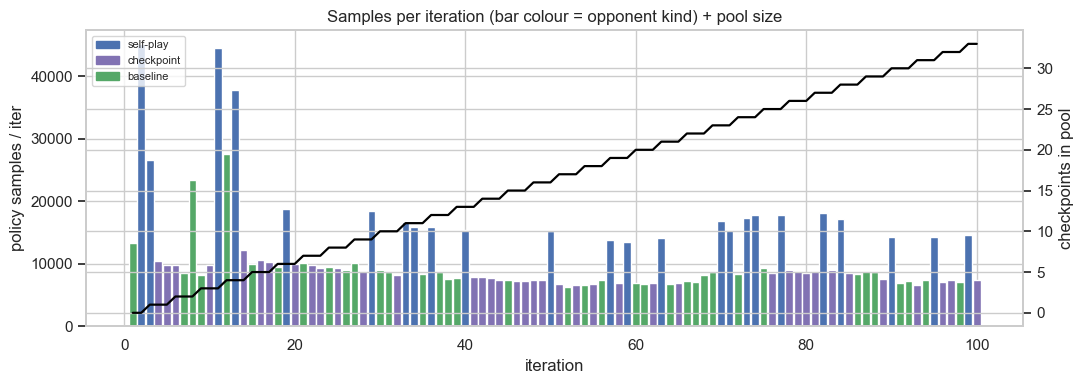

opp_kind
checkpoint    39
baseline      37
self-play     24


In [4]:
def opp_kind(o):
    if o == "self":
        return "self-play"
    if o.endswith(".npz"):
        return "checkpoint"
    return "baseline"

df["opp_kind"] = df["opponent"].map(opp_kind)
colors = {"self-play": "#4c72b0", "checkpoint": "#8172b3", "baseline": "#55a868"}

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(df["iteration"], df["n_samples"], width=0.9,
       color=df["opp_kind"].map(colors))
ax.set_xlabel("iteration")
ax.set_ylabel("policy samples / iter")
ax.set_title("Samples per iteration (bar colour = opponent kind) + pool size")

ax2 = ax.twinx()
ax2.plot(df["iteration"], df["ckpts_after"], c="black", lw=1.6)
ax2.set_ylabel("checkpoints in pool")

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors.values()]
ax.legend(handles, list(colors), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

print(df["opp_kind"].value_counts().to_string())

## 3. Final checkpoint — clean N=500 eval

The in-loop points are 100 games each (±~10pp), too noisy for a keep/drop call.
These are the **N=500** evals of `final.npz` (the last-iterate net OSFP submits),
read from `results/` if present.

In [5]:
for tag, label in [("final_vs_bc", "vs BC net"), ("final_vs_heur", "vs heuristic")]:
    p = ROOT / "results" / f"{tag}.json"
    if not p.exists():
        print(f"{label}: (results/{tag}.json not found)")
        continue
    s = json.loads(p.read_text())
    lo, hi = s["a_winrate_ci95"]
    print(f"{label:14s}: {s['a_winrate']:.3f}  95% CI [{lo:.3f}, {hi:.3f}]  "
          f"-> {s['verdict']}")

vs BC net     : 0.546  95% CI [0.502, 0.589]  -> lean-adopt
vs heuristic  : 0.682  95% CI [0.640, 0.721]  -> adopt


## Takeaways (honest read)

- **vs random**: ~1.0 throughout — crushed, as expected.
- **vs heuristic**: the final net reaches **~0.68 (N=500)**, above BC's 0.604 -
  a real, modest improvement (~+8pp). The in-loop 100-game points oscillate
  (0.52-0.76) purely from noise.
- **vs BC head-to-head**: final **0.546 (N=500, CI [0.502, 0.589])** - *barely*
  above 0.5. This is the §B "保留" band (51-55%), **not** the >=55% clear-adopt
  bar. So OSFP edged BC but did not clearly beat it.
- **Shape**: the per-iteration curve is essentially **flat with high variance** -
  the gain shows up as the **last-iterate** final checkpoint, consistent with
  OSFP's last-iterate convergence (we submit the final net, not an average).

**Why so modest**: ~100x256 ~= 1M samples is *tiny* for self-play RL (the paper
used 3.2e8 samples per learning period). And the default `temperature=1.0`
makes self-play data very exploratory (weak gradient signal).

**Next**: tune (lower/anneal `temperature`, `lr`, epochs/iter), evaluate at
**N≥1000** to resolve the 保留 band, and run longer / on native x86-64 Linux for
more data — then the BC-warm-start-vs-from-scratch ablation. See `PLAN.md`
Phase 5a メモ + 採否台帳.